In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [150]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf 
from tensorflow import keras
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [151]:
ccd2=pd.read_csv("C:/Users/dhany/Downloads/Results_2026-06-27-1404.csv")
ccd2.dtypes

GENDER                                       int64
SENIORCITIZEN                                int64
PARTNER                                      int64
DEPENDENTS                                   int64
TENURE                                       int64
PHONESERVICE                                 int64
MULTIPLELINES                                int64
ONLINESECURITY                               int64
ONLINEBACKUP                                 int64
DEVICEPROTECTION                             int64
TECHSUPPORT                                  int64
STREAMINGTV                                  int64
STREAMINGMOVIES                              int64
PAPERLESSBILLING                             int64
MONTLYCHARGES                              float64
TOTALCHARGES                               float64
CHURN                                        int64
INTERNETSERVICE_DSL                          int64
INTERNETSERVICE_Fiber optic                  int64
INTERNETSERVICE_No             

In [152]:
cols_to_transform=['TENURE','MONTLYCHARGES','TOTALCHARGES']
scaler=MinMaxScaler()
ccd2[cols_to_transform]=scaler.fit_transform(ccd2[cols_to_transform])
ccd2.dtypes

GENDER                                       int64
SENIORCITIZEN                                int64
PARTNER                                      int64
DEPENDENTS                                   int64
TENURE                                     float64
PHONESERVICE                                 int64
MULTIPLELINES                                int64
ONLINESECURITY                               int64
ONLINEBACKUP                                 int64
DEVICEPROTECTION                             int64
TECHSUPPORT                                  int64
STREAMINGTV                                  int64
STREAMINGMOVIES                              int64
PAPERLESSBILLING                             int64
MONTLYCHARGES                              float64
TOTALCHARGES                               float64
CHURN                                        int64
INTERNETSERVICE_DSL                          int64
INTERNETSERVICE_Fiber optic                  int64
INTERNETSERVICE_No             

In [153]:
X=ccd2.drop('CHURN',axis=1)
y=ccd2['CHURN']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [154]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
model = Sequential([ Input(shape=(X_train.shape[1],)), Dense(64, activation='relu'), Dense(32, activation='relu'), Dense(1, activation='sigmoid') ])
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6617 - loss: 0.5883
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7981 - loss: 0.4288
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8071 - loss: 0.4195
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8033 - loss: 0.4158
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8107 - loss: 0.4013
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8047 - loss: 0.4129
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8126 - loss: 0.4023
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8150 - loss: 0.3915
Epoch 9/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8107 - loss: 0.3962
Epoch 10/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8184 - loss: 0.3976
Epoch 11/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8109 - loss: 0.3951
Epoch 12/100
154/154 ━━━━━━━━━━━━━━━━━━━━

In [155]:
model.evaluate(X_test, y_test)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7472 - loss: 0.6583 


[0.649840772151947, 0.7635071277618408]

In [156]:
yp = model.predict(X_test)
yp

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


array([[3.1859649e-04],
       [8.0663316e-02],
       [4.9373236e-01],
       ...,
       [3.2835852e-03],
       [1.9196151e-02],
       [5.4737508e-01]], dtype=float32)

In [157]:
y_pred = []
for element in yp:
    if element > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [158]:
from sklearn.metrics import confusion_matrix , classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1549
           1       0.56      0.52      0.54       561

    accuracy                           0.76      2110
   macro avg       0.69      0.68      0.69      2110
weighted avg       0.76      0.76      0.76      2110



Text(95.72222222222221, 0.5, 'Truth')

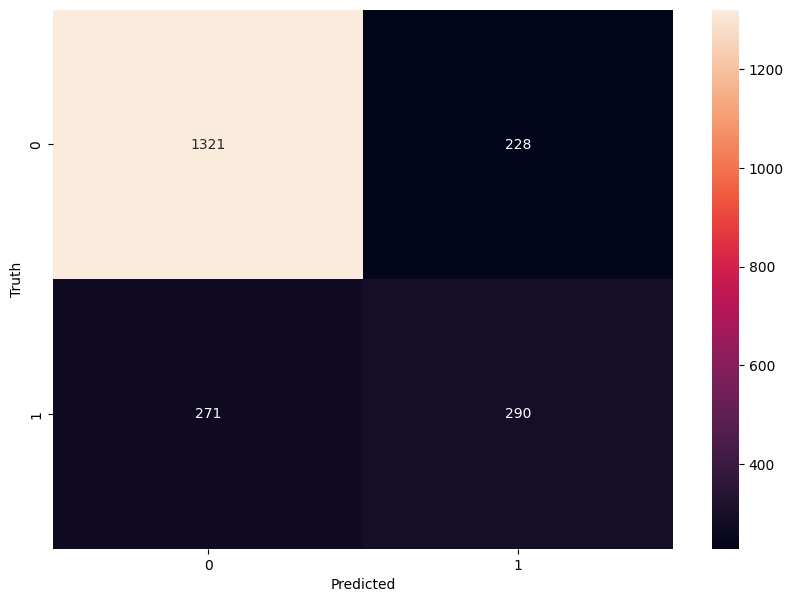

In [159]:
import seaborn as sn
import matplotlib.pyplot as plt
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

ROC AUC: 0.7867274499447059


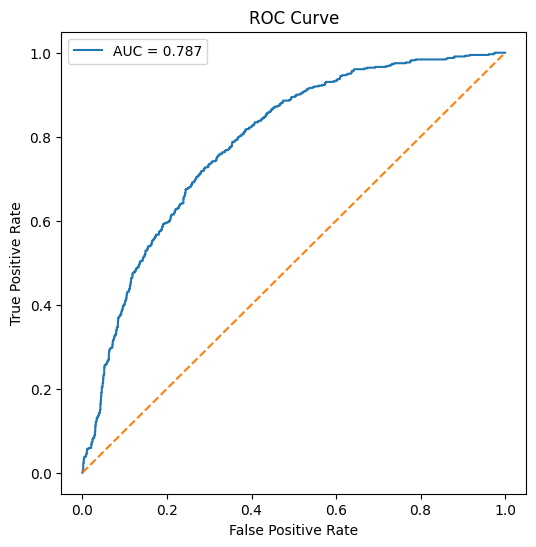

In [162]:
auc = roc_auc_score(y_test, yp)
print("ROC AUC:", auc)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, yp)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()